In [2]:
# Installing all libraries we need for this project
# geopandas — handles geographic/map data
# folium — creates interactive HTML maps
# shap — explains our ML model's decisions later
# openpyxl — reads Excel .xlsx files
# mapclassify — needed by geopandas for map styling
!pip install geopandas folium shap openpyxl mapclassify

print("All installed!")

All installed!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the deprivation CSV file
# We're uploading from our laptop to Colab first
from google.colab import files
uploaded = files.upload()

# Load it into a DataFrame
# This file has thousands of rows — one per small area in England
df_dep = pd.read_csv("File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv")

# First look — what have we got?
print("Shape:", df_dep.shape)
print("\nColumn names:")
print(list(df_dep.columns))
print("\nFirst 3 rows:")
df_dep.head(3)

Saving File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv to File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv
Shape: (32844, 57)

Column names:
['LSOA code (2011)', 'LSOA name (2011)', 'Local Authority District code (2019)', 'Local Authority District name (2019)', 'Index of Multiple Deprivation (IMD) Score', 'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)', 'Income Score (rate)', 'Income Rank (where 1 is most deprived)', 'Income Decile (where 1 is most deprived 10% of LSOAs)', 'Employment Score (rate)', 'Employment Rank (where 1 is most deprived)', 'Employment Decile (where 1 is most deprived 10% of LSOAs)', 'Education, Skills and Training Score', 'Education, Skills and Training Rank (where 1 is most deprived)', 'Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)', 'Health Deprivation and Disability

,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),...,Indoors Sub-domain Rank (where 1 is most deprived),Indoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Outdoors Sub-domain Score,Outdoors Sub-domain Rank (where 1 is most deprived),Outdoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Total population: mid 2015 (excluding prisoners),Dependent Children aged 0-15: mid 2015 (excluding prisoners),Population aged 16-59: mid 2015 (excluding prisoners),Older population aged 60 and over: mid 2015 (excluding prisoners),Working age population 18-59/64: for use with Employment Deprivation Domain (excluding prisoners)
0,E01000001,City of London 001A,E09000001,City of London,6.208,29199,9,0.007,32831,10,...,16364,5,1.503,1615,1,1296,175,656,465,715
1,E01000002,City of London 001B,E09000001,City of London,5.143,30379,10,0.034,29901,10,...,22676,7,1.196,2969,1,1156,182,580,394,620
2,E01000003,City of London 001C,E09000001,City of London,19.402,14915,5,0.086,18510,6,...,17318,6,2.207,162,1,1350,146,759,445,804


In [4]:
# The deprivation file covers ALL of England
# We only want London — filter by local authority name
# London boroughs all appear in the Local Authority District Name column

# First let's see what unique local authorities exist
# This helps us confirm the column name
print("Unique areas sample:")
print(df_dep.iloc[:, 1].unique()[:20])

Unique areas sample:
['City of London 001A' 'City of London 001B' 'City of London 001C'
 'City of London 001E' 'Barking and Dagenham 016A'
 'Barking and Dagenham 015A' 'Barking and Dagenham 015B'
 'Barking and Dagenham 016B' 'Barking and Dagenham 015C'
 'Barking and Dagenham 016C' 'Barking and Dagenham 015D'
 'Barking and Dagenham 013A' 'Barking and Dagenham 013B'
 'Barking and Dagenham 009A' 'Barking and Dagenham 009B'
 'Barking and Dagenham 009C' 'Barking and Dagenham 009D'
 'Barking and Dagenham 023A' 'Barking and Dagenham 023B'
 'Barking and Dagenham 008A']


In [5]:
# The column with borough names is called something like
# "Local Authority District name (2019)"
# We'll call it 'borough' to make life easier
# Replace the column name below with whatever printed above

borough_col = "Local Authority District name (2019)"

# List of all 32 London boroughs + City of London
london_boroughs = [
    "Barking and Dagenham", "Barnet", "Bexley", "Brent", "Bromley",
    "Camden", "City of London", "Croydon", "Ealing", "Enfield",
    "Greenwich", "Hackney", "Hammersmith and Fulham", "Haringey",
    "Harrow", "Havering", "Hillingdon", "Hounslow", "Islington",
    "Kensington and Chelsea", "Kingston upon Thames", "Lambeth",
    "Lewisham", "Merton", "Newham", "Redbridge", "Richmond upon Thames",
    "Southwark", "Sutton", "Tower Hamlets", "Waltham Forest", "Wandsworth",
    "Westminster"
]

# Filter — keep only rows where borough name is in our London list
# .isin() checks if each value is in the list — returns True or False
df_london = df_dep[df_dep[borough_col].isin(london_boroughs)]

print("London rows found:", len(df_london))
print("Boroughs found:", df_london[borough_col].nunique())

London rows found: 4835
Boroughs found: 33


In [6]:
# Upload the crime CSV file
from google.colab import files
import pandas as pd

uploaded = files.upload()

# Get the uploaded file name automatically
filename = list(uploaded.keys())[0]

# Load the CSV into a DataFrame
df_crime = pd.read_csv(filename)

# Look at the dataset
print("Shape:", df_crime.shape)

print("\nColumns:")
print(list(df_crime.columns))

print("\nFirst 3 rows:")
df_crime.head(3)

Saving MPS Borough Level Crime (most recent 24 months).csv to MPS Borough Level Crime (most recent 24 months).csv
Shape: (993, 27)

Columns:
['Group', 'SubGroup', 'BOCU', '202407', '202408', '202409', '202410', '202411', '202412', '202501', '202502', '202503', '202504', '202505', '202506', '202507', '202508', '202509', '202510', '202511', '202512', '202601', '202602', '202603', '202604', '202605', '202606']

First 3 rows:


,Group,SubGroup,BOCU,202407,202408,202409,202410,202411,202412,202501,...,202509,202510,202511,202512,202601,202602,202603,202604,202605,202606
0,ARSON AND CRIMINAL DAMAGE,ARSON,Barking and Dagenham,3,10,9,5,7,9,7,...,5,6,8,7,0,3,3,5,4,7
1,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Barking and Dagenham,131,114,80,103,96,89,106,...,99,103,106,125,104,97,116,109,131,112
2,BURGLARY,BURGLARY BUSINESS AND COMMUNITY,Barking and Dagenham,21,26,32,29,25,22,17,...,23,16,23,23,27,26,22,22,24,19


In [7]:
# Group all tiny area rows by their borough name
# Then average every numeric column across them
# Result: 32 rows — one per London borough
df_dep_borough = df_london.groupby(
    "Local Authority District name (2019)"
).mean(numeric_only=True).reset_index()

# Rename the borough column to something shorter
# Makes merging easier later
df_dep_borough = df_dep_borough.rename(columns={
    "Local Authority District name (2019)": "borough"
})

# Keep only the columns we actually need
# The deprivation score and a few domain scores
# Check your column names and pick the most relevant ones
df_dep_borough = df_dep_borough[[
    "borough",
    "Index of Multiple Deprivation (IMD) Score",
    "Income Score (rate)",
    "Employment Score (rate)",
    "Health Deprivation and Disability Score",
    "Education, Skills and Training Score",
    "Crime Score",
    "Living Environment Score"
]]

# Shorten column names so they're easier to work with
df_dep_borough.columns = [
    "borough",
    "deprivation_score",
    "income_score",
    "employment_score",
    "health_score",
    "education_score",
    "crime_score_dep",
    "environment_score"
]

print("Shape:", df_dep_borough.shape)
print("\nFirst 5 boroughs:")
df_dep_borough.head(5)

Shape: (33, 8)

First 5 boroughs:


,borough,deprivation_score,income_score,employment_score,health_score,education_score,crime_score_dep,environment_score
0,Barking and Dagenham,32.883473,0.194218,0.118964,0.223418,25.842509,0.537709,28.923664
1,Barnet,15.953626,0.109185,0.071972,-1.086427,7.736261,0.078649,24.320185
2,Bexley,15.882363,0.102247,0.074911,-0.574342,18.281685,-0.146774,19.678630
3,Brent,25.199855,0.154023,0.096578,-0.459335,14.797491,0.421318,28.434983
4,Bromley,13.969447,0.089711,0.066325,-0.910467,10.511751,-0.041695,18.186294


In [8]:
#so since deprivaiton file had envorimental score we got rid off air qulIT INDEX AS THE INFO IS ALREADY REPSENT - HERE IS THE CODE PART FOR THAT
# Print all 57 column names clearly
# We're looking for environment and living related ones
for i, col in enumerate(df_dep_borough.columns):
    print(f"{i}: {col}")

0: borough
1: deprivation_score
2: income_score
3: employment_score
4: health_score
5: education_score
6: crime_score_dep
7: environment_score


In [9]:
# These are the living environment columns in IoD2019
# They're already in your df_dep_borough after Cell 6

# "environment_score" — this is what we renamed it to in Cell 6
# It comes from "Living Environment Score" in the original file

# It's made up of two sub-domains:
# 1. Indoors living environment (housing quality, overcrowding)
# 2. Outdoors living environment — THIS includes air quality
#    specifically NO2 and PM10 concentrations from LAEI data

# So when you see this in your master table:
print(df_dep_borough[["borough", "environment_score"]].head(10))

                borough  environment_score
0  Barking and Dagenham          28.923664
1                Barnet          24.320185
2                Bexley          19.678630
3                 Brent          28.434983
4               Bromley          18.186294
5                Camden          33.287241
6        City of London          40.370167
7               Croydon          25.294818
8                Ealing          30.216602
9               Enfield          27.238885


In [10]:
# The date columns are all the monthly count columns
# Everything except Group, SubGroup and BOCU is a month
# We select just the month columns by dropping the non-numeric ones

# Step 1 — identify the month columns
# These are all columns except the first 3 descriptive ones
month_cols = [col for col in df_crime.columns if col not in ["Group", "SubGroup", "BOCU"]]

# col for col in list means — go through each column name
# if it's not one of the three text columns, keep it
# result: a list of just the date columns like ['202407', '202408'...]
print("Month columns found:", len(month_cols))

# Step 2 — add a total column
# Sum all monthly counts across each row into one number
# axis=1 means sum across columns (left to right) not rows
df_crime["total_crime"] = df_crime[month_cols].sum(axis=1)

# Step 3 — group by borough (BOCU column) and sum total crimes
# Each borough has many rows (one per crime type)
# We add them all up to get one total crime count per borough
df_crime_borough = df_crime.groupby("BOCU")["total_crime"].sum().reset_index()

# Rename BOCU to borough so it matches our other datasets
df_crime_borough = df_crime_borough.rename(columns={
    "BOCU": "borough",
    "total_crime": "total_crime_count"
})

print(
    df_crime_borough
    .sort_values("total_crime_count", ascending=False)
    .reset_index(drop=True)
)

Month columns found: 24
                   borough  total_crime_count
0              Westminster             166740
1                   Newham              83071
2                   Camden              82825
3                Southwark              81774
4                  Lambeth              77209
5            Tower Hamlets              75101
6                  Croydon              70156
7                  Hackney              66271
8                    Brent              66033
9                   Ealing              64879
10               Islington              63040
11              Hillingdon              62516
12                Lewisham              60311
13                 Enfield              59641
14                  Barnet              58137
15                Haringey              57564
16               Greenwich              56341
17                Hounslow              54231
18              Wandsworth              53426
19               Redbridge              49240
20        

In [11]:
# Now we join deprivation and crime together on borough name
# pd.merge() works like VLOOKUP in Excel
# left= first table, right= second table
# on= the shared column to match on
# how="inner" means only keep boroughs that exist in BOTH tables

df_master = pd.merge(
    df_dep_borough,     # deprivation data — 32 boroughs
    df_crime_borough,   # crime data — 32 boroughs
    on="borough",       # match on borough name
    how="inner"         # only keep rows that match in both
)

print("Master table shape:", df_master.shape)
print("\nColumns:", list(df_master.columns))
print("\nFirst 5 rows:")
df_master.head()

Master table shape: (32, 9)

Columns: ['borough', 'deprivation_score', 'income_score', 'employment_score', 'health_score', 'education_score', 'crime_score_dep', 'environment_score', 'total_crime_count']

First 5 rows:


,borough,deprivation_score,income_score,employment_score,health_score,education_score,crime_score_dep,environment_score,total_crime_count
0,Barking and Dagenham,32.883473,0.194218,0.118964,0.223418,25.842509,0.537709,28.923664,40768
1,Barnet,15.953626,0.109185,0.071972,-1.086427,7.736261,0.078649,24.320185,58137
2,Bexley,15.882363,0.102247,0.074911,-0.574342,18.281685,-0.146774,19.678630,32517
3,Brent,25.199855,0.154023,0.096578,-0.459335,14.797491,0.421318,28.434983,66033
4,Bromley,13.969447,0.089711,0.066325,-0.910467,10.511751,-0.041695,18.186294,48746


In [12]:
# Sometimes borough names are spelled slightly differently
# between datasets — this catches any that didn't merge

# Check how many boroughs we got
print("Boroughs in master table:", len(df_master))

# If less than 32, some names didn't match
# Find which crime boroughs didn't match deprivation boroughs
crime_boroughs = set(df_crime_borough["borough"])
dep_boroughs   = set(df_dep_borough["borough"])

# Boroughs in crime data but not in deprivation
unmatched = crime_boroughs - dep_boroughs
if unmatched:
    print("\nUnmatched boroughs — fix these:")
    print(unmatched)
else:
    print("\nAll boroughs matched perfectly!")

# Save master table to CSV
df_master.to_csv("master_london.csv", index=False)
print("\nSaved as master_london.csv")
print(df_master.dtypes)

Boroughs in master table: 32

Unmatched boroughs — fix these:
{'Unknown'}

Saved as master_london.csv
borough               object
deprivation_score    float64
income_score         float64
employment_score     float64
health_score         float64
education_score      float64
crime_score_dep      float64
environment_score    float64
total_crime_count      int64
dtype: object


In [13]:
# 'Unknown' is not a real borough
# it's just unrecorded crime data — remove it
df_crime_borough = df_crime_borough[
    df_crime_borough["borough"] != "Unknown"
]

# Re-run the merge with the clean crime data
df_master = pd.merge(
    df_dep_borough,
    df_crime_borough,
    on="borough",
    how="inner"
)

# Save the clean version
df_master.to_csv("master_london.csv", index=False)

print("Shape:", df_master.shape)
print("All boroughs matched perfectly!")

Shape: (32, 9)
All boroughs matched perfectly!


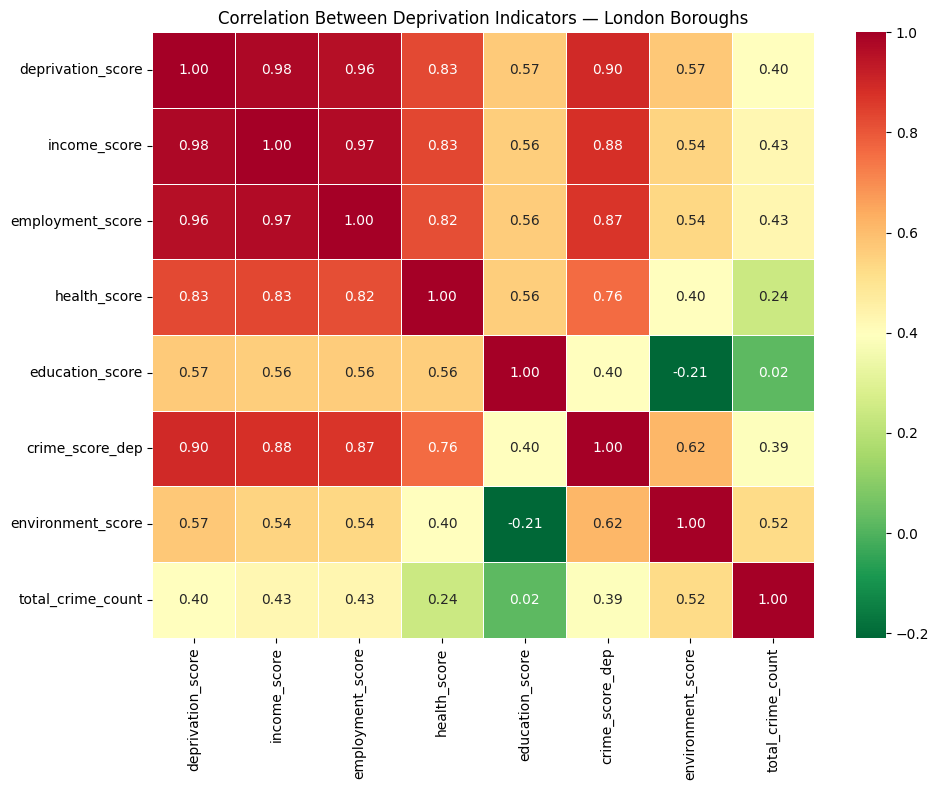

In [14]:
import seaborn as sns

# Select only the numeric columns for correlation
# We want to see which variables relate to deprivation score
numeric_cols = [
    "deprivation_score",
    "income_score",
    "employment_score",
    "health_score",
    "education_score",
    "crime_score_dep",
    "environment_score",
    "total_crime_count"
]

# .corr() calculates correlation between every pair of columns
# Result is a grid — each cell shows how strongly two variables relate
# 1.0 = perfect positive correlation
# -1.0 = perfect negative correlation
# 0 = no relationship
corr_matrix = df_master[numeric_cols].corr()

# Draw the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # show numbers inside each cell
    fmt=".2f",         # round to 2 decimal places
    cmap="RdYlGn_r",   # red = high correlation, green = low
    linewidths=0.5     # thin lines between cells
)
plt.title("Correlation Between Deprivation Indicators — London Boroughs")
plt.tight_layout()
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# X = the features — everything except borough name and deprivation score
# These are the things the model uses to PREDICT deprivation
# Think of these as the "ingredients" we feed the model
X = df_master[[
    "income_score",
    "employment_score",
    "health_score",
    "education_score",
    "crime_score_dep",
    "environment_score",
    "total_crime_count"
]]

# y = the target — what we're trying to predict
# The model will learn to predict this number
y = df_master["deprivation_score"]

# Split data into training set and test set
# test_size=0.2 means 20% goes to testing (about 6 boroughs)
# 80% is used to train the model (about 26 boroughs)
# random_state=42 means we get the same split every time we run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training on:", len(X_train), "boroughs")
print("Testing on:", len(X_test), "boroughs")

# Create the Random Forest model
# n_estimators=100 means 100 decision trees voting together
# random_state=42 keeps results consistent each run
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model — this is where it learns patterns
# .fit() shows the model the training data and lets it learn
model.fit(X_train, y_train)

print("\nModel trained!")

# Now test it on boroughs it has never seen
# .predict() asks the model to guess deprivation scores
y_pred = model.predict(X_test)

# R² score — how well does the model explain the data?
# 1.0 = perfect, 0.0 = no better than guessing the average
r2 = r2_score(y_test, y_pred)

# RMSE — average error in deprivation score points
# Lower is better
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR² Score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"\nThe model explains {r2*100:.1f}% of deprivation variance")

Training on: 25 boroughs
Testing on: 7 boroughs

Model trained!

R² Score: 0.897
RMSE: 1.404

The model explains 89.7% of deprivation variance


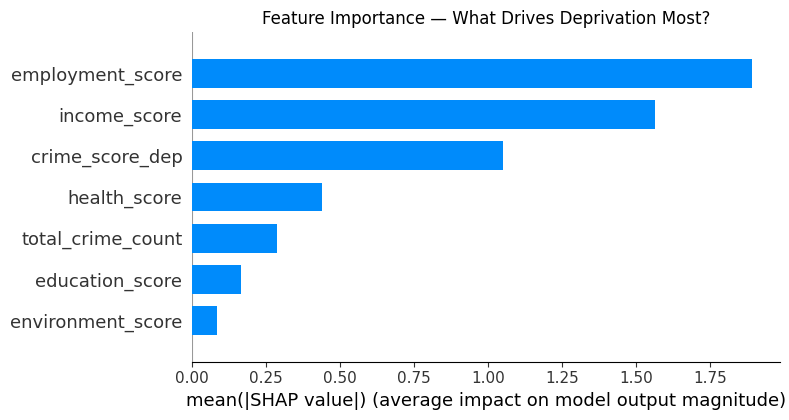

Chart saved!


In [16]:
import shap

# Create a SHAP explainer using our trained model
# TreeExplainer is specifically designed for tree-based models
# like Random Forest — much faster than other explainers
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for ALL our data
# shap_values tells us — for each borough and each feature
# how much did that feature push the prediction up or down?
shap_values = explainer.shap_values(X)

# Plot 1 — Summary bar chart
# Shows which features matter MOST overall across all boroughs
# Longer bar = more important feature
plt.figure()
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",     # bar chart version
    show=False
)
plt.title("Feature Importance — What Drives Deprivation Most?")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved!")

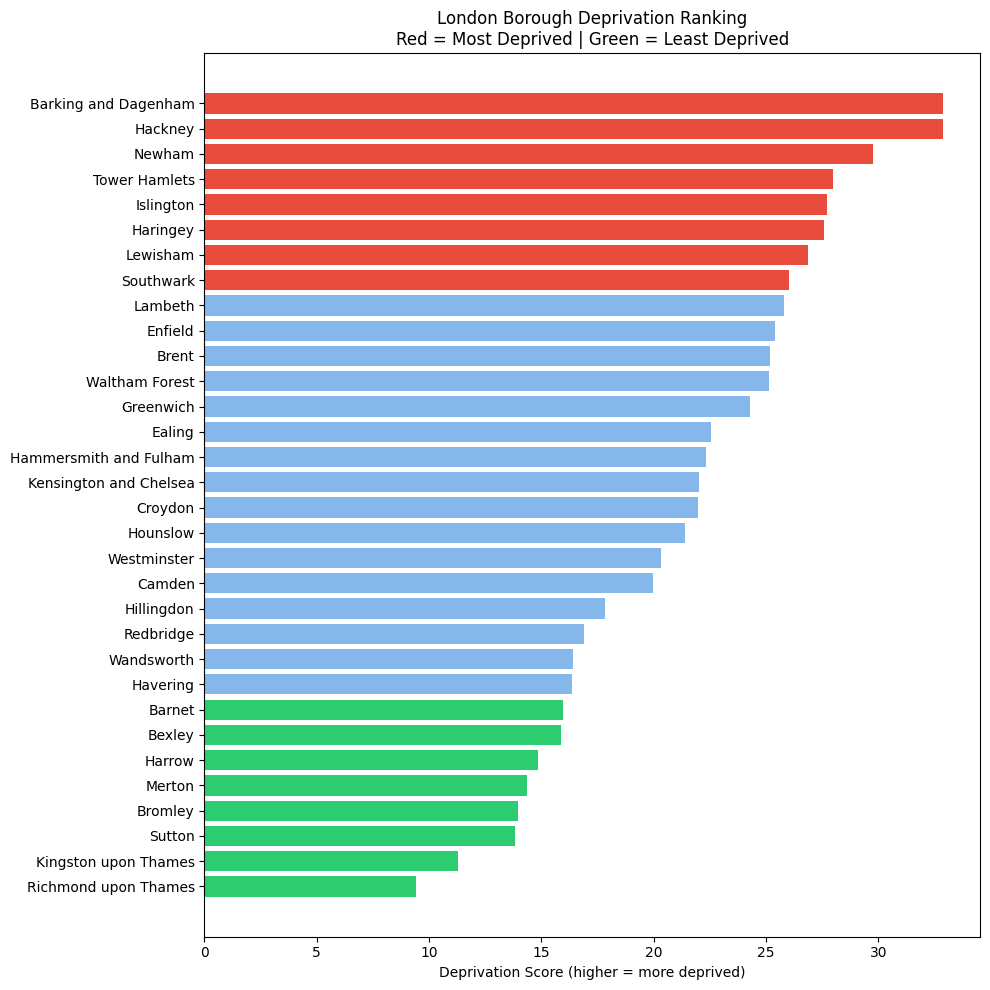

Chart 2 done!


In [19]:
# ============================================================
# CHART 2 — Borough Deprivation Ranking
# "Which London boroughs are most and least deprived?"
# Horizontal bar chart — every borough ranked top to bottom
# Red = most deprived, Green = least deprived, Blue = middle
# Easy for anyone to read — no data science knowledge needed
# Perfect for your Streamlit dashboard and Erasmus paper
# ============================================================

df_sorted = df_master.sort_values("deprivation_score", ascending=True)

# Colour each bar based on deprivation level
# quantile(0.75) = top 25% most deprived = red
# quantile(0.25) = bottom 25% least deprived = green
# everything in between = blue
colors = []
for score in df_sorted["deprivation_score"]:
    if score > df_master["deprivation_score"].quantile(0.75):
        colors.append("#E74C3C")   # red — most deprived
    elif score < df_master["deprivation_score"].quantile(0.25):
        colors.append("#2ECC71")   # green — least deprived
    else:
        colors.append("#85B7EB")   # blue — middle

plt.figure(figsize=(10, 10))
plt.barh(
    df_sorted["borough"],
    df_sorted["deprivation_score"],
    color=colors
)
plt.xlabel("Deprivation Score (higher = more deprived)")
plt.title("London Borough Deprivation Ranking\nRed = Most Deprived | Green = Least Deprived")
plt.tight_layout()
plt.savefig("chart2_borough_ranking.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 done!")

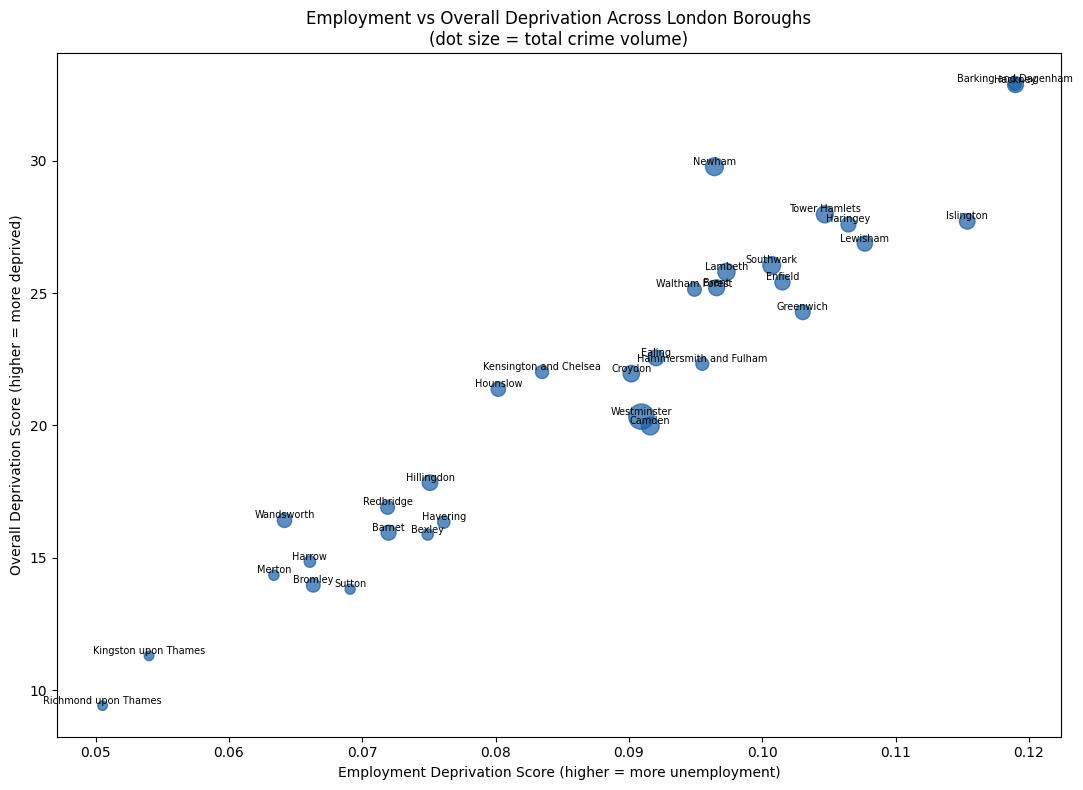

Chart 3 done!


In [20]:
# ============================================================
# CHART 3 — Employment vs Deprivation Scatter Plot
# "Does high unemployment mean high deprivation?"
# Each dot = one London borough, labelled by name
# X axis = employment deprivation (how many can't work)
# Y axis = overall deprivation score
# If dots go from bottom-left to top-right = strong relationship
# Dot size = total crime volume in that borough
# This PROVES your SHAP finding visually
# ============================================================

plt.figure(figsize=(11, 8))

# scatter() draws the dots
# s= controls dot size — divide by 500 so they're not huge
# alpha= makes dots slightly transparent so overlapping ones show
plt.scatter(
    df_master["employment_score"],
    df_master["deprivation_score"],
    s=df_master["total_crime_count"] / 500,
    alpha=0.7,
    color="#185FA5"
)

# Label every single borough by name on the chart
for _, row in df_master.iterrows():
    plt.annotate(
        row["borough"],
        (row["employment_score"], row["deprivation_score"]),
        fontsize=7,
        ha="center",
        va="bottom"
    )

plt.xlabel("Employment Deprivation Score (higher = more unemployment)")
plt.ylabel("Overall Deprivation Score (higher = more deprived)")
plt.title("Employment vs Overall Deprivation Across London Boroughs\n(dot size = total crime volume)")
plt.tight_layout()
plt.savefig("chart3_employment_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 done!")

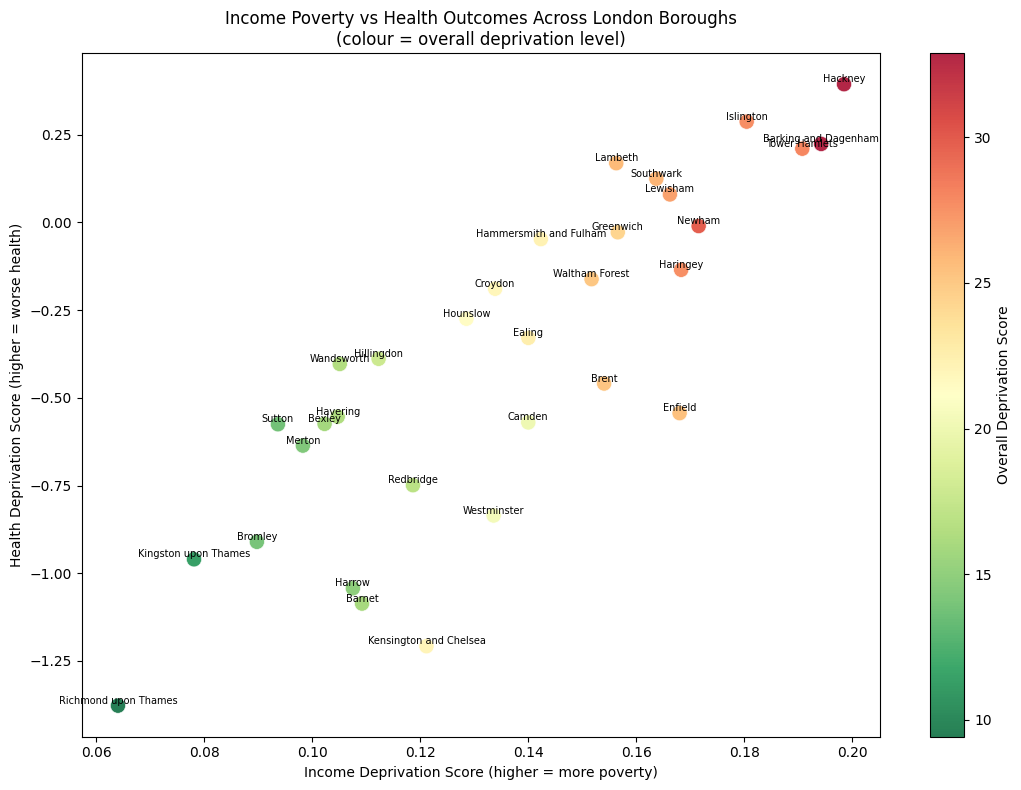

Chart 4 done!


In [21]:
# ============================================================
# CHART 4 — Income vs Health Scatter (social story chart)
# "Do poorer boroughs also have worse health outcomes?"
# Each dot = one borough
# X axis = income deprivation score
# Y axis = health deprivation score
# If yes — dots go from bottom-left to top-right
# This tells the human story behind the numbers
# Shows poverty and poor health go hand in hand in London
# ============================================================

plt.figure(figsize=(11, 8))

# Draw dots coloured by deprivation level
# Use the deprivation score to colour each dot
scatter = plt.scatter(
    df_master["income_score"],
    df_master["health_score"],
    c=df_master["deprivation_score"],  # colour = overall deprivation
    cmap="RdYlGn_r",                   # red = high deprivation, green = low
    s=120,
    alpha=0.85,
    edgecolors="white",
    linewidth=0.5
)

# Add a colour bar on the side showing what colours mean
plt.colorbar(scatter, label="Overall Deprivation Score")

# Label every borough
for _, row in df_master.iterrows():
    plt.annotate(
        row["borough"],
        (row["income_score"], row["health_score"]),
        fontsize=7,
        ha="center",
        va="bottom"
    )

plt.xlabel("Income Deprivation Score (higher = more poverty)")
plt.ylabel("Health Deprivation Score (higher = worse health)")
plt.title("Income Poverty vs Health Outcomes Across London Boroughs\n(colour = overall deprivation level)")
plt.tight_layout()
plt.savefig("chart4_income_health.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 4 done!")

In [22]:
#What each chart proves in your paper:

#Chart 1 — which factor matters most (employment)
#Chart 2 — which boroughs are worst (Newham, Tower Hamlets, Hackney likely top)
#Chart 3 — employment directly drives deprivation (proves Chart 1 visually)
#Chart 4 — poverty and poor health are inseparable in London (the human story)

# ============================================================
# DOWNLOAD ALL 4 CHARTS TO YOUR LAPTOP
# ============================================================
from google.colab import files
files.download("chart1_shap_importance.png")
files.download("chart2_borough_ranking.png")
files.download("chart3_employment_scatter.png")
files.download("chart4_income_health.png")
print("All charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All charts downloaded!


In [23]:
import folium
import requests
import json
import pandas as pd

# Download London borough boundaries directly from the internet
# This is a GeoJSON file — it contains the shape of every London borough
# GeoJSON is like a map drawing file — it tells Python where to draw each borough
url = "https://raw.githubusercontent.com/radoi90/housequest-data/master/london_boroughs.geojson"

# requests.get() fetches the file from the internet
response = requests.get(url)

# Convert the response to a Python dictionary
geojson_data = response.json()

# Check what boroughs are in the file
# Each feature = one borough shape
print("Boroughs in GeoJSON file:")
for feature in geojson_data["features"]:
    print(feature["properties"]["name"])

Boroughs in GeoJSON file:
Barking and Dagenham
Barnet
Bexley
Brent
Bromley
Camden
City of London
Croydon
Ealing
Enfield
Greenwich
Hackney
Hammersmith and Fulham
Haringey
Harrow
Havering
Hillingdon
Hounslow
Islington
Kensington and Chelsea
Kingston upon Thames
Lambeth
Lewisham
Merton
Newham
Redbridge
Richmond upon Thames
Southwark
Sutton
Tower Hamlets
Waltham Forest
Wandsworth
Westminster


In [24]:
# FOLIUM MAP — Interactive London Deprivation Map
# Each borough coloured by deprivation score
# Click any borough to see its full stats in a popup

# Step 1 — create the base map
# location= sets the starting centre point (London coordinates)
# zoom_start= sets how zoomed in it starts
# tiles= sets the map style — "CartoDB positron" is clean and light
m = folium.Map(
    location=[51.5074, -0.1278],
    zoom_start=10,
    tiles="CartoDB positron"
)

# Step 2 — create a choropleth layer
# This is what colours each borough based on deprivation score
# geo_data= the GeoJSON file with borough shapes
# data= our master table with deprivation scores
# columns= which columns to link — borough name + the score
# key_on= the property in GeoJSON that matches our borough names
# fill_color= colour scheme — YlOrRd = yellow to orange to red
# Higher deprivation = darker red
folium.Choropleth(
    geo_data=geojson_data,
    data=df_master,
    columns=["borough", "deprivation_score"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="Deprivation Score (higher = more deprived)",
    highlight=True
).add_to(m)

# Step 3 — add clickable popups for each borough
# When user clicks a borough they see all its stats
# We loop through each borough in our master table
for _, row in df_master.iterrows():

    # Find the matching borough shape in the GeoJSON
    # We need the coordinates to place the popup in the right spot
    for feature in geojson_data["features"]:
        if feature["properties"]["name"] == row["borough"]:

            # Get the centre coordinates of this borough
            # We calculate these from the GeoJSON coordinates
            coords = feature["geometry"]["coordinates"]

            # For simple polygons take the first ring
            # For multipolygons take the largest ring
            if feature["geometry"]["type"] == "Polygon":
                points = coords[0]
            else:
                # MultiPolygon — find the largest polygon
                points = max(coords, key=lambda x: len(x[0]))[0]

            # Calculate rough centre by averaging all coordinates
            # This puts the popup marker in the middle of the borough
            lat = sum(p[1] for p in points) / len(points)
            lng = sum(p[0] for p in points) / len(points)

            # Build the popup HTML — what appears when you click
            # We use HTML to make it look clean and formatted
            popup_html = f"""
            <div style="font-family: Arial; width: 220px; padding: 8px;">
                <h4 style="margin:0; color:#185FA5;">
                    {row['borough']}
                </h4>
                <hr style="margin: 6px 0;">
                <table style="width:100%; font-size:12px;">
                    <tr>
                        <td><b>Deprivation Score</b></td>
                        <td style="text-align:right">
                            {row['deprivation_score']:.1f}
                        </td>
                    </tr>
                    <tr>
                        <td><b>Income Score</b></td>
                        <td style="text-align:right">
                            {row['income_score']:.3f}
                        </td>
                    </tr>
                    <tr>
                        <td><b>Employment Score</b></td>
                        <td style="text-align:right">
                            {row['employment_score']:.3f}
                        </td>
                    </tr>
                    <tr>
                        <td><b>Health Score</b></td>
                        <td style="text-align:right">
                            {row['health_score']:.3f}
                        </td>
                    </tr>
                    <tr>
                        <td><b>Education Score</b></td>
                        <td style="text-align:right">
                            {row['education_score']:.3f}
                        </td>
                    </tr>
                    <tr>
                        <td><b>Total Crimes</b></td>
                        <td style="text-align:right">
                            {int(row['total_crime_count']):,}
                        </td>
                    </tr>
                </table>
            </div>
            """

            # Add a circle marker at the borough centre
            # popup= what appears when clicked
            # tooltip= what appears on hover
            folium.CircleMarker(
                location=[lat, lng],
                radius=6,
                color="#185FA5",
                fill=True,
                fill_opacity=0.7,
                popup=folium.Popup(popup_html, max_width=250),
                tooltip=f"{row['borough']} — Score: {row['deprivation_score']:.1f}"
            ).add_to(m)
            break

# Step 4 — save the map as an HTML file
# This creates a fully interactive map you can open in any browser
m.save("london_deprivation_map.html")
print("Map saved! Opening now...")

# Step 5 — display the map right here in Colab
# This shows a preview inside your notebook
from IPython.display import display
display(m)

Map saved! Opening now...


In [25]:
from google.colab import files
files.download("master_london.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>